## Packages

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from hlp_eme.core import eme_funs
from hlp_eme.core import physics
from hlp_eme.core import grating_struct_funs
from pathlib import Path
from scipy.io import loadmat
from hlp_eme.core import visualize_funs
from hlp_eme.lum import get_lumapi
lumapi = get_lumapi()

C:\Program Files\Lumerical\v202\api\python\lumapi.py:797: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


## HLP-EME simulation preparation

### grating Params

This code contains three simulation examples below. Uncomment one to activate it.

#### 1-Ch. square filter

In [ ]:
# qn_name = '1c_sq_n1710_p302'
# qn_file_path = Path('grating_libs') / f'{qn_name}.mat'
# qn = loadmat(qn_file_path)
# qn = np.squeeze(qn['qn'])
# zn = range(len(qn))
# period_nm = 302
# qn_norm, _ = visualize_funs.complex_qn_normalize(qn=qn)
# _ = visualize_funs.plot_qn(qn_norm=qn_norm, period_um=period_nm/1e3)

# w_wg_um = 1
# is_mc = True
# lam_um_center_eme = 1.555
# dw_nm = 55
# wg_thickness_um = 0.22
# design_name = '1c_sq' # this label will be used as the prefix of the simulation file name


#### 2-Ch. linear edge filter

In [ ]:
# qn_name = '2c_edge_filter_n3551_p302'
# qn_file_path = Path('grating_libs') / f'{qn_name}.mat'
# qn = loadmat(qn_file_path)
# qn = np.squeeze(qn['qn'])
# zn = range(len(qn))
# period_nm = 302
# qn_norm, _ = visualize_funs.complex_qn_normalize(qn=qn)
# _ = visualize_funs.plot_qn(qn_norm=qn_norm, period_um=period_nm/1e3)

# w_wg_um = 1
# is_mc = True
# lam_um_center_eme = 1.555
# dw_nm = 30
# wg_thickness_um = 0.22
# design_name = '2c_edge' # this label will be used as the prefix of the simulation file name


#### Gau. apodied filter

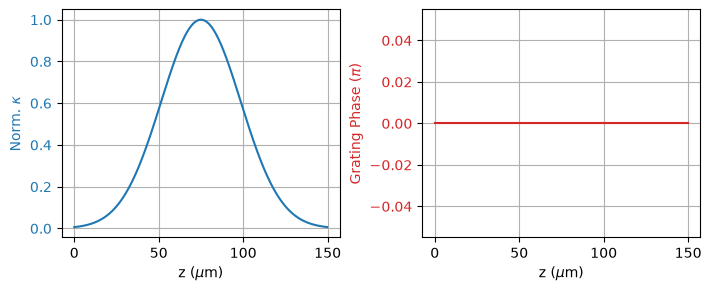

In [4]:
period_nm = 300
w_wg_um = 1
is_mc = True
dw_nm = 40
n_periods = 500
lam_um_center_eme = 1.548
zn = np.arange(n_periods)
qn_norm = np.exp(-4 * np.log(2) * ((zn - np.ceil(n_periods / 2)) / (n_periods / 2.7))**2)
_ = visualize_funs.plot_qn(qn_norm=qn_norm, period_um=period_nm/1e3)
wg_thickness_um = 0.22
design_name = 'gau_n500' # this label will be used as the prefix of the simulation file name


### simulation Params

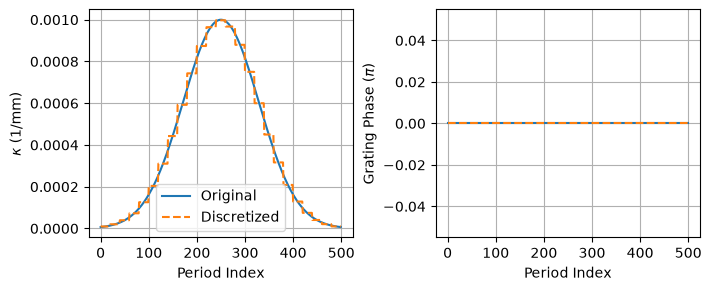

In [ ]:
n_periods_per_block = 20
n_slices_per_period = 7
qn_norm_piecewise = physics.piecewised(qn_norm, n_periods_per_block=n_periods_per_block, plot=True)
n_modes = 5 # number of modes used in the EME solving
y_mesh_step_nm = 4 # y-axis mesh step used in the override mesh covering the corrugation region; chosen according to `dw_nm`
y_bc = 'PML'
mesh_cells_y = 100 # number of mesh cells within the entire EME y-span

## wavelength sweep Param.
lam_um_span = 0.026
start_lam_um = lam_um_center_eme-lam_um_span/2
end_lam_um = lam_um_center_eme+lam_um_span/2
n_lams = 300

# margin between grating and simulation boundary, which sets to half of effective wavelength
eme_margin_um = end_lam_um/1.445/2

### grating Struct. generation

In [7]:
group_params, plot_data = grating_struct_funs.generate_eme_grating_data(
    qn_norm_piecewise=qn_norm_piecewise,
    n_periods=len(qn_norm_piecewise),
    period_um=period_nm*1e-3,
    w_wg_um=w_wg_um,
    delta_w_um=dw_nm*1e-3,
    n_periods_per_block=n_periods_per_block,
    qn_norm_org=qn_norm,  
    mc=is_mc,
    n_slices_per_period=n_slices_per_period, 
)
n_blocks = len(group_params)
print(f'Verify: the length of `group_params` is {n_blocks}')

Verify: the length of `group_params` is 25


verify the structure (optional)

In [ ]:
# grating_struct_funs.verify_eme_grating(
#     group_params=group_params,
#     plot_data=plot_data,
#     draw_block_range=(15, 16),
#     plot_only_struct4=False
# )

## Initilzie EME Session and Configure the simulation

open a new session of Lumerica Mode

In [11]:
s = lumapi.MODE(hideR=False)

add the grating Struct to EME

In [12]:
l_compressed_grating = eme_funs.add_apodized_grating_group_for_eme(
    s=s,
    group_params=group_params,
    x0=0.0,
    thick=wg_thickness_um,
    lead_length=1.0,
    material="Si (Silicon) - Palik",
    group_name="Apodized_Grating_Group",
)

add an EME solver

In [13]:
eme_funs.add_eme(
    s, 
    y_span=w_wg_um+eme_margin_um*2, 
    z_span=wg_thickness_um+eme_margin_um*2, 
    z_min_bc='Symmetric', 
    z_max_bc='Metal',
    y_max_bc=y_bc,
    y_min_bc=y_bc,
    mesh_cells_y=mesh_cells_y,
    center_wavelength_um=lam_um_center_eme
    )

configures EME cell group definitions and periodic block replication.

In [14]:
(
    flat_group_spans,
    cells_per_group,
    periodic_starts,
    periodic_ends,
    periodic_periods,
) = eme_funs.eme_cell_setting_data_gen(group_params)

assert len(flat_group_spans) == n_blocks, (
    f"len(flat_group_spans) ({len(flat_group_spans)}) != n_blocks ({n_blocks})"
)
assert len(group_params) == n_blocks, (
    f"len(group_params) ({len(group_params)}) != n_blocks ({n_blocks})"
)

subcell_methods = [1] * n_blocks  

print(f"Configuring EME with {n_blocks} individual cell groups...")

eme_funs.set_cell_basic(
    s,
    n_cell_groups=n_blocks,
    group_spans=flat_group_spans,
    cells_per_group=cells_per_group,
    subcell_methods=subcell_methods,
    custom_eigensolver_settings=True,
    n_modes=n_modes
)


print("Setting up periodic definitions...")

eme_funs.set_periodic_groups(
    s,
    n_of_periodic_groups=len(group_params),
    periods_cell_groups=periodic_periods,
    start_cell_group=periodic_starts,
    end_cell_group=periodic_ends
)

print("Configuration Done.")


Configuring EME with 25 individual cell groups...
Setting up periodic definitions...
Configuration Done.


add override mesh over the grating corrugation region

In [15]:
eme_funs.add_mesh_grating(s, x_max=l_compressed_grating*1e6, dy_nm=y_mesh_step_nm, dw_nm=dw_nm, w_wg=w_wg_um,)

set the port modes

In [16]:
mode_list_port1, mode_list_port2 = [1, 2], [1, 2]
eme_funs.set_ports(
    s, 
    selected_mode_numbers_port1=mode_list_port1,
    selected_mode_numbers_port2=mode_list_port2,
    )


save the simulation file

In [ ]:
sim_file_name, _ = eme_funs.save_lms_file(
    s=s,
    w_wg_um=w_wg_um,
    period_nm=period_nm,
    design_name=design_name,
    dw_nm=dw_nm,
    n_blocks=n_blocks,
    n_periods_per_block=n_periods_per_block,
    n_slices_per_period=n_slices_per_period,
    mc=is_mc,
    save=True
    )

run the simulation and perform wavelength sweep

In [ ]:
print('EME running...')
s.run()
print('Wavelength sweeping...')
lams_nm_eme, sweep_data = eme_funs.run_eme_lam_sweep(
    s=s, 
    start_lam_um=start_lam_um, 
    end_lam_um=end_lam_um, 
    n_lams=n_lams
    )
print('Done!')


plot the wavelength sweep result

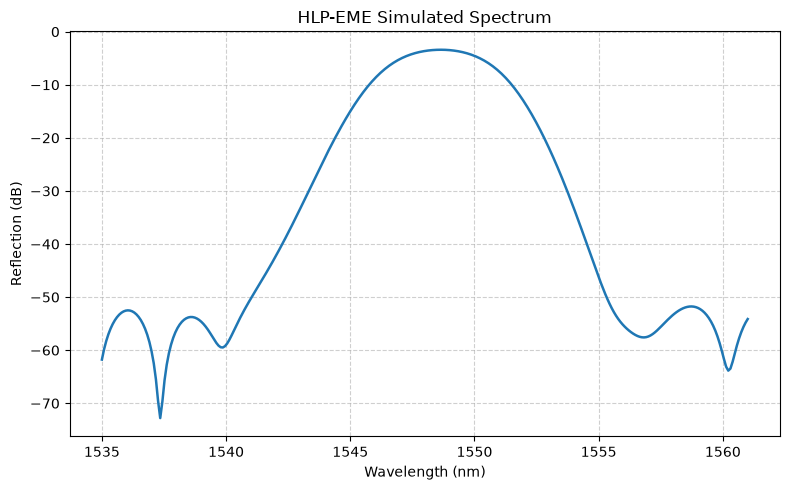

In [37]:
r_smatrix_label = 's12' # s12 refers to te0-te1 reflection here; carefully select this label according to different gratings
reflection_coeff = sweep_data[r_smatrix_label].squeeze()
reflection_db = physics.lin2db(reflection_coeff)

plt.figure(figsize=(8, 5))
plt.plot(lams_nm_eme, reflection_db, label='Reflection (dB)', lw=1.8)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflection (dB)')  
plt.title('HLP-EME Simulated Spectrum')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
# plt.legend()
plt.tight_layout()
plt.show()


save the wavelength sweep result

In [38]:
eme_res_data_name = sim_file_name+'.npz'
np.savez(eme_res_data_name, wavelength_nm=lams_nm_eme, reflection_db=reflection_db)

close the simulation session

In [21]:
s.close()

## Compare HLP-EME and CMT-TMM results

#### compute CMT-TMM spectrum

In [ ]:
sim_lams_params = {
    'lam_nm_center': lam_um_center_eme*1e3, 
    'lam_nm_span': 20, 
    'n_lams': 200
}
kappa_max = 17000
kappa_arr = qn_norm * kappa_max
lams_nm_cmt, t_cmt, r_cmt = physics.grating_response_cal(
    qn=kappa_arr, 
    sim_lam_params=sim_lams_params,
    grating_period_nm=period_nm,
    plot=False,
)
r_cmt_db = physics.lin2db(r_cmt)

load the HLP-EME result data and plot the comparison

In [39]:
eme_res_data_name = 'mc_gau_n500_w1_p300_dw40_nb25_np20_ns7'+'.npz'
eme_res_data = np.load(eme_res_data_name)
lams_nm_eme = eme_res_data['wavelength_nm']
reflection_db = eme_res_data['reflection_db']


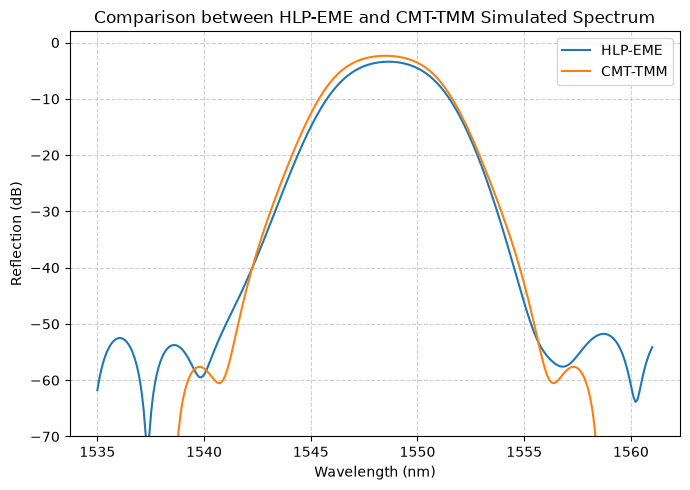

In [44]:
plt.figure(figsize=(7,5))
lam_nm_offet = 0.5 # align the two spectra
plt.plot(lams_nm_eme, reflection_db, label='HLP-EME')
plt.plot(lams_nm_cmt+lam_nm_offet, r_cmt_db, label='CMT-TMM')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflection (dB)')  
plt.title('Comparison between HLP-EME and CMT-TMM Simulated Spectrum')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(-70, 2)
plt.tight_layout()
plt.grid(True)

